
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/nasdorm/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/nasdorm/Library/Python/3.11/lib/python/site-packages/traitlets/config/application.py", line 1043, in launch_instance
    app.start()
  File "/Users/nasdorm/Library/Python/3.11/lib/python/site-packages/ipykernel/kernelapp.py", line 725, in start
    self.io_loop.sta

AttributeError: _ARRAY_API not found

Загружаем SBER...
Загружаем IMOEX...
Загружаем USD/RUB (USD000UTSTOM)...
Число строк после очистки: 2993
X_train: (1775, 20, 8) y_train: (1775, 1)
X_test: (1178, 20, 8) y_test: (1178, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 224)        │       208,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 224)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 20, 32)         │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 32)             │            52 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,941 (929.46 KB)

 Trainable params: 237,941 (929.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0301 - val_loss: 0.0035
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0029 - val_loss: 0.0040
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0022 - val_loss: 0.0047
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0020 - val_loss: 0.0027
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0020 - val_loss: 0.0024
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0015 - val_loss: 0.0021
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0017 - val_loss: 0.0033
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0016 - val_loss: 0.0023
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 

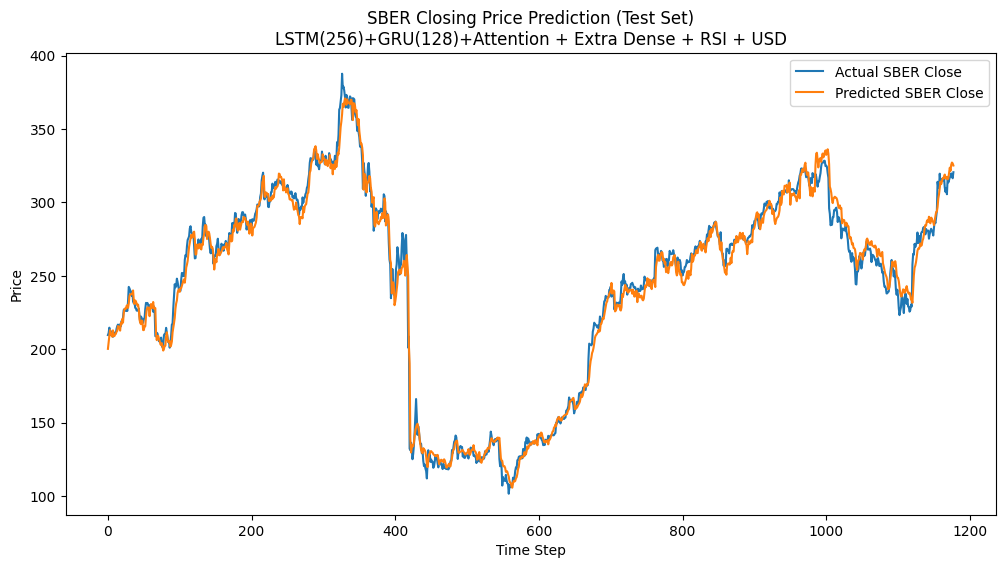

In [1]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error

# ============================================================
# Блок 1. Функции для загрузки данных с MOEX
# ============================================================

def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    """
    Пагинированная загрузка исторических (EOD) данных с MOEX (OPEN, HIGH, LOW, CLOSE, VOLUME и т.д.).
    Возвращает DataFrame или None при ошибке.
    """
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100

    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break

    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None


def compute_rsi(series, period=14):
    """
    Вычисляет RSI для переданного pd.Series цен закрытия.
    Возвращает pd.Series с RSI (в начале будут NaN).
    """
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi


# ============================================================
# Блок 2. Кастомный слой внимания (Attention)
# ============================================================
class AttentionLayer(Layer):
    """
    Простой слой внимания для временных рядов:
    1) e = XW + b
    2) alpha = softmax(e)
    3) Суммируем входы с весами alpha, получая контекст
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        # input_shape: (batch_size, timesteps, hidden_dim)
        hidden_dim = input_shape[-1]
        self.W = self.add_weight(
            name='att_weight',
            shape=(hidden_dim, 1),
            initializer='glorot_uniform'
        )
        self.b = self.add_weight(
            name='att_bias',
            shape=(input_shape[1], 1),  # (timesteps, 1)
            initializer='zeros'
        )
        super().build(input_shape)

    def call(self, inputs):
        # inputs: (batch_size, timesteps, hidden_dim)
        e = tf.tensordot(inputs, self.W, axes=[[2],[0]]) + self.b  # (batch, timesteps, 1)
        e = tf.squeeze(e, axis=-1)  # (batch, timesteps)
        alpha = tf.nn.softmax(e)    # (batch, timesteps)
        alpha = tf.expand_dims(alpha, axis=-1)  # (batch, timesteps, 1)
        context = inputs * alpha
        context = tf.reduce_sum(context, axis=1)  # (batch, hidden_dim)
        return context


# ============================================================
# Блок 3. Основной скрипт
# ============================================================
if __name__ == "__main__":
    # -------------------------------------
    # 3.1 Параметры
    # -------------------------------------
    start_date = "2013-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")

    # -------------------------------------
    # 3.2 ЗАГРУЗКА ДАННЫХ
    # -------------------------------------
    print("Загружаем SBER...")
    sber_df = fetch_moex_eod_data("SBER", "stock", "shares", "TQBR", start_date, end_date)
    
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    
    print("Загружаем USD/RUB (USD000UTSTOM)...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)

    if sber_df is None or imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке датасетов.")

    # -------------------------------------
    # 3.3 ПРЕДОБРАБОТКА
    # -------------------------------------
    sber_df["TRADEDATE"] = pd.to_datetime(sber_df["TRADEDATE"])
    imoex_df["TRADEDATE"] = pd.to_datetime(imoex_df["TRADEDATE"])
    usd_df["TRADEDATE"]   = pd.to_datetime(usd_df["TRADEDATE"])

    sber_df.sort_values("TRADEDATE", inplace=True)
    imoex_df.sort_values("TRADEDATE", inplace=True)
    usd_df.sort_values("TRADEDATE", inplace=True)

    # Переименуем столбцы
    sber_df.rename(columns={"CLOSE": "CLOSE_SBER"}, inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)

    # Оставим нужные поля
    sber_df = sber_df[["TRADEDATE", "OPEN", "HIGH", "LOW", "CLOSE_SBER", "VOLUME"]]
    sber_df.rename(columns={
        "OPEN": "OPEN_SBER",
        "HIGH": "HIGH_SBER",
        "LOW": "LOW_SBER",
        "VOLUME": "VOL_SBER"
    }, inplace=True)

    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df   = usd_df[["TRADEDATE", "CLOSE_USD"]]

    # Объединим
    merged_df = sber_df.merge(imoex_df, on="TRADEDATE", how="outer").merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)

    # Удаляем строки с пропусками
    merged_df.dropna(subset=["CLOSE_SBER", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)

    # Добавим RSI для SBER
    merged_df["RSI_SBER"] = compute_rsi(merged_df["CLOSE_SBER"], period=14)
    merged_df.dropna(subset=["RSI_SBER"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)

    print(f"Число строк после очистки: {len(merged_df)}")

    # -------------------------------------
    # 3.4 Формирование признаков и разделение
    # -------------------------------------
    features = [
        "OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER",
        "CLOSE_IMOEX", "CLOSE_USD", "RSI_SBER"
    ]
    target_cols = ["CLOSE_SBER"]  # Предсказываем только Сбер (можно расширить)

    data = merged_df[features].values.astype(float)
    targets = merged_df[target_cols].values.astype(float)

    total_len = len(data)
    train_end = int(0.6 * total_len)
    train_data = data[:train_end]
    test_data  = data[train_end:]
    train_targets = targets[:train_end]
    test_targets  = targets[train_end:]

    # Масштабируем отдельно X и y
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    scaler_X.fit(train_data)
    scaler_y.fit(train_targets)

    train_data_scaled = scaler_X.transform(train_data)
    test_data_scaled  = scaler_X.transform(test_data)
    train_targets_scaled = scaler_y.transform(train_targets)
    test_targets_scaled  = scaler_y.transform(test_targets)

    # Функция для формирования скользящих окон (t+1)
    # Если хотите multi-step (например, t+5), меняйте логику в цикле.
    def create_sequences(X, y, seq_length=30):
        X_seq, y_seq = [], []
        for i in range(len(X) - seq_length):
            X_seq.append(X[i:i+seq_length])
            y_seq.append(y[i + seq_length])
        return np.array(X_seq), np.array(y_seq)

    seq_length = 20
    X_train, y_train = create_sequences(train_data_scaled, train_targets_scaled, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, test_targets_scaled, seq_length)

    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)

    # -------------------------------------
    # 3.5 Модель LSTM(128) + GRU(64) + Attention + Dense
    # -------------------------------------
    from tensorflow.keras import Input
    input_layer = Input(shape=(seq_length, len(features)))

    # Первый слой LSTM
    x = LSTM(224, return_sequences=True)(input_layer)
    x = Dropout(0.1)(x)

    # Второй слой GRU
    x = GRU(32, return_sequences=True)(x)
    x = Dropout(0.1)(x)

    # Attention
    x = AttentionLayer()(x)

    # Дополнительный Dense-слой после внимания
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.1)(x)

    # Выход
    output_layer = Dense(len(target_cols))(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    # При желании: optimizer="RMSprop" или "Nadam"
    model.compile(optimizer="Nadam", loss="mse")
    model.summary()

    early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=16,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    # -------------------------------------
    # 3.6 Оценка и визуализация
    # -------------------------------------
    test_loss = model.evaluate(X_test, y_test, verbose=1)
    print("Test Loss (MSE):", test_loss)

    preds_scaled = model.predict(X_test)
    preds = scaler_y.inverse_transform(preds_scaled)
    actuals = scaler_y.inverse_transform(y_test)

    # Визуализируем для SBER
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label="Actual SBER Close")
    plt.plot(preds, label="Predicted SBER Close")
    plt.title("SBER Closing Price Prediction (Test Set)\nLSTM(256)+GRU(128)+Attention + Extra Dense + RSI + USD")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()


In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_orig = mean_squared_error(actuals, preds)
mae_orig = mean_absolute_error(actuals, preds)
rmse_orig = np.sqrt(mse_orig)

print(f"MSE (original scale, рубли^2): {mse_orig:.4f}")
print(f"RMSE (original scale, рубли):  {rmse_orig:.4f}")
print(f"MAE (original scale, рубли):   {mae_orig:.4f}")

mape = np.mean(np.abs(actuals - preds) / actuals) * 100
print(f"MAPE: {mape:.2f}%")

MSE (original scale, рубли^2): 55.5321
RMSE (original scale, рубли):  7.4520
MAE (original scale, рубли):   5.3946
MAPE: 2.30%


# Pytorch version

Загружаем данные SBER с MOEX...
Загружаем IMOEX...
Загружаем USD/RUB...
Число строк после очистки: 2994
X_train: (1776, 20, 8) y_train: (1776, 1)
X_test: (1178, 20, 8) y_test: (1178, 1)
Epoch 1/50 - Loss: 0.0252 - Val Loss: 0.0138
Epoch 2/50 - Loss: 0.0038 - Val Loss: 0.0066
Epoch 3/50 - Loss: 0.0038 - Val Loss: 0.0065
Epoch 4/50 - Loss: 0.0028 - Val Loss: 0.0056
Epoch 5/50 - Loss: 0.0028 - Val Loss: 0.0059
Epoch 6/50 - Loss: 0.0032 - Val Loss: 0.0094
Epoch 7/50 - Loss: 0.0028 - Val Loss: 0.0045
Epoch 8/50 - Loss: 0.0028 - Val Loss: 0.0049
Epoch 9/50 - Loss: 0.0026 - Val Loss: 0.0159
Epoch 10/50 - Loss: 0.0024 - Val Loss: 0.0036
Epoch 11/50 - Loss: 0.0023 - Val Loss: 0.0057
Epoch 12/50 - Loss: 0.0022 - Val Loss: 0.0051
Epoch 13/50 - Loss: 0.0023 - Val Loss: 0.0076
Epoch 14/50 - Loss: 0.0019 - Val Loss: 0.0068
Epoch 15/50 - Loss: 0.0018 - Val Loss: 0.0057
Epoch 16/50 - Loss: 0.0017 - Val Loss: 0.0028
Epoch 17/50 - Loss: 0.0018 - Val Loss: 0.0052
Epoch 18/50 - Loss: 0.0017 - Val Loss: 0.

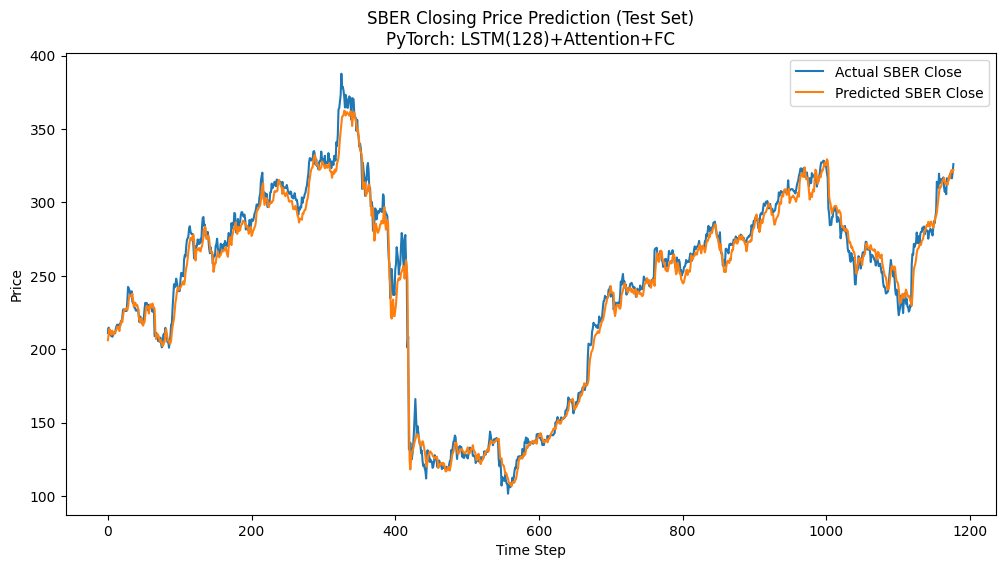

In [5]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ============================================================
# 1. Функции для загрузки данных и предобработки
# ============================================================
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def preprocess_data(df, ticker):
    # Приведение даты к datetime и сортировка
    df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
    df.sort_values("TRADEDATE", inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Переименование столбцов для уникальности
    close_col = f"CLOSE_{ticker}"
    open_col  = f"OPEN_{ticker}"
    high_col  = f"HIGH_{ticker}"
    low_col   = f"LOW_{ticker}"
    vol_col   = f"VOL_{ticker}"
    df.rename(columns={
        "CLOSE": close_col,
        "OPEN": open_col,
        "HIGH": high_col,
        "LOW": low_col,
        "VOLUME": vol_col
    }, inplace=True)
    
    # Вычисление RSI для цены закрытия
    rsi_col = f"RSI_{ticker}"
    df[rsi_col] = compute_rsi(df[close_col], period=14)
    df.dropna(subset=[rsi_col], inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    return df

def create_sequences(X, y, seq_length=20):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# ============================================================
# 2. Определение модели на PyTorch
# ============================================================
class AttentionLayer(nn.Module):
    """
    Кастомный слой внимания.
    Принимает вход размером (batch, timesteps, hidden_dim) и возвращает вектор (batch, hidden_dim)
    """
    def __init__(self, hidden_dim, timesteps):
        super(AttentionLayer, self).__init__()
        self.hidden_dim = hidden_dim
        self.timesteps = timesteps
        self.W = nn.Parameter(torch.Tensor(hidden_dim, 1))
        self.b = nn.Parameter(torch.zeros(timesteps, 1))
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.W)
    
    def forward(self, x):
        # x: (batch, timesteps, hidden_dim)
        # e = x @ W + b -> (batch, timesteps, 1)
        e = torch.matmul(x, self.W) + self.b  # (batch, timesteps, 1)
        e = e.squeeze(-1)  # (batch, timesteps)
        alpha = torch.softmax(e, dim=1)  # (batch, timesteps)
        alpha = alpha.unsqueeze(-1)  # (batch, timesteps, 1)
        context = x * alpha  # (batch, timesteps, hidden_dim)
        context = torch.sum(context, dim=1)  # (batch, hidden_dim)
        return context

class PricePredictionModel(nn.Module):
    def __init__(self, seq_length, num_features, output_dim, lstm_units, fc_units, dropout_rate):
        super(PricePredictionModel, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        # Attention: timesteps = seq_length, hidden_dim = lstm_units
        self.attention = AttentionLayer(hidden_dim=lstm_units, timesteps=seq_length)
        self.fc1 = nn.Linear(lstm_units, fc_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_units, output_dim)
    
    def forward(self, x):
        # x: (batch, seq_length, num_features)
        lstm_out, _ = self.lstm(x)  # (batch, seq_length, lstm_units)
        x = self.dropout(lstm_out)
        attn_out = self.attention(x)  # (batch, lstm_units)
        x = self.fc1(attn_out)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ============================================================
# 3. Основной скрипт для тикера SBER
# ============================================================
if __name__ == "__main__":
    ticker = "SBER"
    start_date = "2010-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    
    print("Загружаем данные SBER с MOEX...")
    sber_df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    print("Загружаем USD/RUB...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if sber_df is None or imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    for df in [sber_df, imoex_df, usd_df]:
        df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
        df.sort_values("TRADEDATE", inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    sber_df.rename(columns={"CLOSE": "CLOSE_SBER", "OPEN": "OPEN_SBER", "HIGH": "HIGH_SBER", "LOW": "LOW_SBER", "VOLUME": "VOL_SBER"}, inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    
    sber_df = sber_df[["TRADEDATE", "OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER"]]
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df   = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    merged_df = sber_df.merge(imoex_df, on="TRADEDATE", how="outer").merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    merged_df.dropna(subset=["CLOSE_SBER", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    merged_df["RSI_SBER"] = compute_rsi(merged_df["CLOSE_SBER"], period=14)
    merged_df.dropna(subset=["RSI_SBER"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    print(f"Число строк после очистки: {len(merged_df)}")
    
    # Формирование признаков и целевой переменной
    features = ["OPEN_SBER", "HIGH_SBER", "LOW_SBER", "CLOSE_SBER", "VOL_SBER",
                "CLOSE_IMOEX", "CLOSE_USD", "RSI_SBER"]
    target_col = "CLOSE_SBER"
    
    data = merged_df[features].values.astype(float)
    targets = merged_df[[target_col]].values.astype(float)
    
    # Разбивка на train/test (60% train, 40% test)
    total_len = len(data)
    train_end = int(0.6 * total_len)
    train_data = data[:train_end]
    test_data = data[train_end:]
    train_targets = targets[:train_end]
    test_targets = targets[train_end:]
    
    # Масштабирование данных
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaler_X.fit(train_data)
    scaler_y.fit(train_targets)
    train_data_scaled = scaler_X.transform(train_data)
    test_data_scaled  = scaler_X.transform(test_data)
    train_targets_scaled = scaler_y.transform(train_targets)
    test_targets_scaled  = scaler_y.transform(test_targets)
    
    # Формирование скользящих окон (последовательностей)
    seq_length = 20
    X_train, y_train = create_sequences(train_data_scaled, train_targets_scaled, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, test_targets_scaled, seq_length)
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)
    
    # Преобразуем в тензоры и создаем DataLoader
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    # Параметры модели
    device = torch.device("mps" if torch.mps.is_available() else "cpu")
    model_pt = PricePredictionModel(seq_length, len(features), output_dim=1,
                                    lstm_units=128, fc_units=64, dropout_rate=0.1)
    model_pt.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model_pt.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    # Тренировочный цикл с ранней остановкой и градиентным клиппингом
    num_epochs = 50
    patience = 10
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model_pt.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model_pt(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_pt.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = np.mean(train_losses)
        
        model_pt.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model_pt(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        scheduler.step(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model_pt.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping!")
                break

    model_pt.load_state_dict(best_model_state)
    
    # Оценка модели
    model_pt.eval()
    test_losses = []
    preds_list = []
    actual_list = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model_pt(X_batch)
            loss = criterion(outputs, y_batch)
            test_losses.append(loss.item())
            preds_list.append(outputs.cpu().numpy())
            actual_list.append(y_batch.cpu().numpy())
    avg_test_loss = np.mean(test_losses)
    print("Test Loss (MSE):", avg_test_loss)
    
    preds = np.concatenate(preds_list, axis=0)
    actuals = np.concatenate(actual_list, axis=0)
    
    # Обратное масштабирование
    preds_inv = scaler_y.inverse_transform(preds)
    actuals_inv = scaler_y.inverse_transform(actuals)
    
    mse_orig = mean_squared_error(actuals_inv, preds_inv)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = np.mean(np.abs(actuals_inv - preds_inv))
    mape_orig = np.mean(np.abs((actuals_inv - preds_inv) / actuals_inv)) * 100
    
    print(f"Метрики для SBER:")
    print(f"MSE (рубли^2): {mse_orig:.3f}")
    print(f"RMSE (рубли):  {rmse_orig:.3f}")
    print(f"MAE (рубли):   {mae_orig:.3f}")
    print(f"MAPE:          {mape_orig:.2f}%")
    
    plt.figure(figsize=(12,6))
    plt.plot(actuals_inv.flatten(), label="Actual SBER Close")
    plt.plot(preds_inv.flatten(), label="Predicted SBER Close")
    plt.title("SBER Closing Price Prediction (Test Set)\nPyTorch: LSTM(128)+Attention+FC")
    plt.xlabel("Time Step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()
